In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [3]:
## arabi is arabi tomato is rice

In [4]:
arabi_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/Rice_arabi_cold/Ortho_vs_gene_files/arabi_gene_results.csv', index_col= 0)
arabi_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/Rice_arabi_cold/Ortho_vs_gene_files/arabi_ortho_trimmed_out_2_gene_families.csv', index_col= 0)
tomato_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/Rice_arabi_cold/Ortho_vs_gene_files/rice_gene_results.csv', index_col= 0)
tomato_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/Rice_arabi_cold/Ortho_vs_gene_files/rice_ortho_trimmed_out_2_gene_families.csv', index_col= 0)

In [5]:
log_fc_change_evaluation_value = 1.5
log_fc_change_evaluation_value_negative = -1*log_fc_change_evaluation_value

In [6]:
tomato_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10238at3193,117.912928,-0.059689,0.360002,-0.165801,0.868314,0.999922
103112at3193,20.844517,0.039788,0.987437,0.040295,0.967858,0.999922
104149at3193,555.821329,0.057582,0.222150,0.259201,0.795480,0.999922
105395at3193,112.654517,0.223998,0.459666,0.487305,0.626042,0.999922
105793at3193,442.618276,0.015548,0.238639,0.065153,0.948052,0.999922
...,...,...,...,...,...,...
9789at3193,364.792970,0.028603,0.279973,0.102164,0.918626,0.999922
9797at3193,83.057230,-0.218619,0.478628,-0.456762,0.647842,0.999922
9814at3193,197.698917,0.282419,0.310953,0.908239,0.363752,0.999922
9942at3193,1544.703011,0.065439,0.172387,0.379602,0.704241,0.999922


In [7]:
trimmed_tomato_ortho = tomato_ortho.loc[tomato_ortho.index.isin(arabi_ortho.index)]
trimmed_arabi_ortho = arabi_ortho.loc[arabi_ortho.index.isin(trimmed_tomato_ortho.index)]


In [8]:
trimmed_arabi_ortho_named = trimmed_arabi_ortho.rename(columns = {'log2FoldChange':'Arabidopsis Log2FC'})
trimmed_tomato_ortho_named = trimmed_tomato_ortho.rename(columns = {'log2FoldChange':'Tomato Log2FC'})



In [9]:
merged_ortho_df = trimmed_arabi_ortho_named[['Arabidopsis Log2FC']].merge(right = trimmed_tomato_ortho_named, left_index= True, right_index = True)

In [10]:
merged_ortho_df

,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj
10772at3193,0.707963,48.421092,-0.008752,0.570016,-0.015354,0.987750,0.999922
10950at3193,0.012729,4398.178535,0.018003,0.161355,0.111572,0.911163,0.999922
109808at3193,0.301060,317.664035,0.079179,0.262645,0.301467,0.763058,0.999922
109841at3193,-0.033875,142.863201,-0.269754,0.343990,-0.784190,0.432929,0.999922
109843at3193,0.744674,1018.641389,-0.073367,0.193558,-0.379043,0.704656,0.999922
...,...,...,...,...,...,...,...
9450at3193,-0.883490,3245.010606,0.164117,0.169092,0.970578,0.331759,0.999922
9592at3193,-0.392489,530.673522,0.135438,0.215421,0.628712,0.529538,0.999922
9601at3193,-0.117255,1007.380153,0.085511,0.186651,0.458133,0.646857,0.999922
9609at3193,-1.164428,781.300994,-0.218419,0.257859,-0.847047,0.396969,0.999922


In [11]:
log_fc_change_evaluation_value

1.5

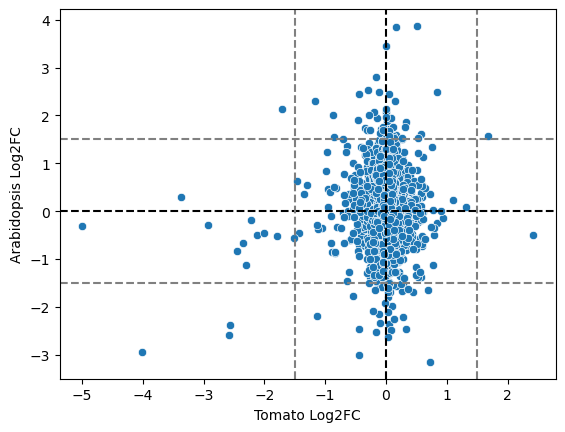

In [12]:
sns.scatterplot(data = merged_ortho_df, x ='Tomato Log2FC', y = 'Arabidopsis Log2FC' )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

Text(0, 0.5, 'Orthogroup-wise log2-fold change in \n Arabidopsis Cold Stress')

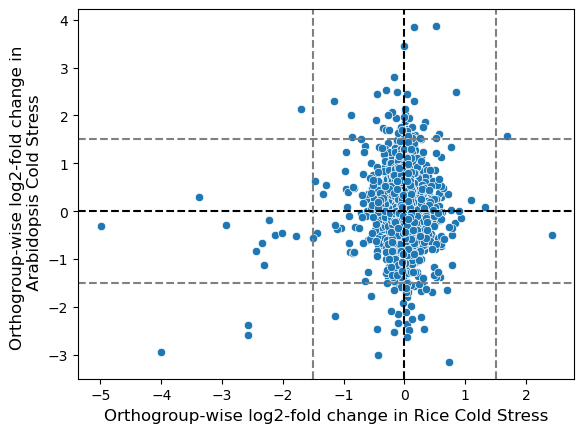

In [13]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.xlabel("Orthogroup-wise log2-fold change in Rice Cold Stress", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in \n Arabidopsis Cold Stress", fontsize = 12)

In [14]:
trimmed_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10772at3193,1280.255464,0.707963,0.096189,7.360097,1.837765e-13,1.425199e-12
10950at3193,506.926572,0.012729,0.108233,0.117607,9.063788e-01,9.373186e-01
109808at3193,330.349166,0.301060,0.132553,2.271244,2.313223e-02,4.431748e-02
109841at3193,94.411249,-0.033875,0.186825,-0.181320,8.561162e-01,8.977190e-01
109843at3193,552.096083,0.744674,0.112576,6.614832,3.719733e-11,2.406113e-10
...,...,...,...,...,...,...
9450at3193,1008.296221,-0.883490,0.098800,-8.942212,3.814578e-19,4.563406e-18
9592at3193,238.979169,-0.392489,0.138469,-2.834489,4.589898e-03,1.058492e-02
9601at3193,203.979398,-0.117255,0.135781,-0.863561,3.878291e-01,4.876525e-01
9609at3193,23.739177,-1.164428,0.332634,-3.500625,4.641683e-04,1.306559e-03


In [15]:
all(trimmed_arabi_ortho.index == trimmed_tomato_ortho.index)

True

In [16]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]

In [17]:
merged_result['Classification'] = 'Non-substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_3228963/2994845458.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_3228963/2994845458.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because

Text(0, 0.5, 'Orthogroup-wise log2-fold change in \n Arabidopsis Cold Stress')

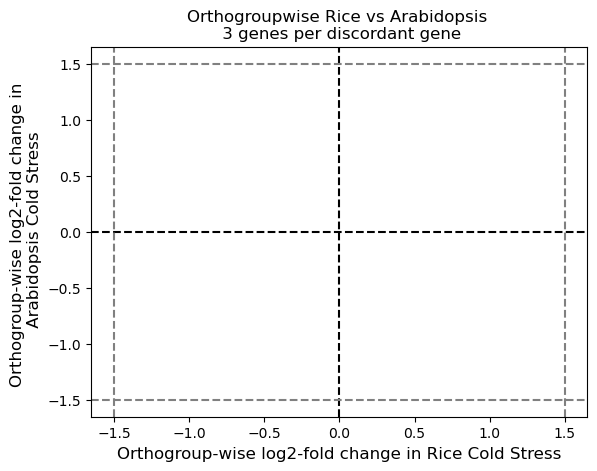

In [18]:
sns.scatterplot(data = merged_result.loc[merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.title('Orthogroupwise Rice vs Arabidopsis \n 3 genes per discordant gene')
plt.xlabel("Orthogroup-wise log2-fold change in Rice Cold Stress", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in \n Arabidopsis Cold Stress", fontsize = 12)

In [19]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

4.0

In [20]:
discord_bottom

,Tomato,Arabi


In [21]:
discord_top

,Tomato,Arabi
148,-1.709189,2.129589


In [22]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])
pos_thresh = 1
neg_thresh = 1
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.921326076199901
0.921326076199901
0.921326076199901
0.921326076199901


In [23]:
arabi_disconcordant_change

,Tomato,Arabi
9,0.516899,3.870857
15,-0.116749,1.241914
28,0.157323,1.078718
44,-0.107866,1.217285
48,0.155985,3.848413
...,...,...
1981,-0.041946,1.688233
1987,0.259250,1.531137
1999,0.272009,1.044847
2009,-0.095634,1.144827


In [24]:
tomato_any_change

,Tomato,Arabi
0,-0.008752,0.707963
1,0.018003,0.012729
2,0.079179,0.301060
3,-0.269754,-0.033875
4,-0.073367,0.744674
...,...,...
2016,0.164117,-0.883490
2017,0.135438,-0.392489
2018,0.085511,-0.117255
2019,-0.218419,-1.164428


In [25]:
tomato_concordant_change

,Tomato,Arabi
0,-0.008752,0.707963
1,0.018003,0.012729
2,0.079179,0.301060
3,-0.269754,-0.033875
4,-0.073367,0.744674
...,...,...
2016,0.164117,-0.883490
2017,0.135438,-0.392489
2018,0.085511,-0.117255
2019,-0.218419,-1.164428


In [26]:
arabidopsis_tomato_nm = pd.read_csv('/vault/transfer/passala/OrthoDB_data/V_11_pairwise_maps_fixed_problem_species/rice_jp_to_arabidopsis_ortholog_NM.csv')

In [27]:
arabidopsis_tomato_nm

,rice_jp OrthoGene,arabidopsis OrthoGene,Orthogroup,rice_jp Symbol,arabidopsis Symbol
0,39947_0:0033f9,3702_0:001f5f,10092at3193,Os05g0333200,AT2G26300
1,39947_0:005347,3702_0:000e32,10147at3193,Os08g0137200,AT1G73910
2,39947_0:005347,3702_0:0018a2,10147at3193,Os08g0137200,AT1G18450
3,39947_0:00028f,3702_0:000573,10228at3193,Os01g0575500,AT1G49040
4,39947_0:001fe4,3702_0:0012bf,10238at3193,Os03g0668400,AT1G79120
...,...,...,...,...,...
42864,39947_0:0048a3,3702_0:003134,9942at3193,Os07g0271000,AT3G59920
42865,39947_0:0020d4,3702_0:005540,9942at3193,Os03g0277000,AT5G09550
42866,39947_0:003388,3702_0:005540,9942at3193,Os05g0304400,AT5G09550
42867,39947_0:003b6c,3702_0:005540,9942at3193,Os05g0418000,AT5G09550


In [28]:
arabi_symbol = 'arabidopsis Symbol'
tomato_symbol = 'rice_jp Symbol'

In [29]:
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = arabi_symbol,)
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = tomato_symbol,)
arabidopsis_tomato_nm

,rice_jp OrthoGene,arabidopsis OrthoGene,Orthogroup,rice_jp Symbol,arabidopsis Symbol
0,39947_0:0033f9,3702_0:001f5f,10092at3193,Os05g0333200,AT2G26300
1,39947_0:005347,3702_0:000e32,10147at3193,Os08g0137200,AT1G73910
3,39947_0:00028f,3702_0:000573,10228at3193,Os01g0575500,AT1G49040
4,39947_0:001fe4,3702_0:0012bf,10238at3193,Os03g0668400,AT1G79120
6,39947_0:001992,3702_0:0003d0,10488at3193,LOC4329458,AT1G08260
...,...,...,...,...,...
42850,39947_0:006dee,3702_0:00121f,9828at3193,Os12g0638900,AT1G74750
42852,39947_0:003d49,3702_0:0052b3,9836at3193,LOC4340090,AT5G11380
42853,39947_0:00158e,3702_0:001def,9877at3193,Os02g0232400,AT2G42790
42856,39947_0:00335b,3702_0:00114d,9919at3193,Os05g0519500,AT1G15440


In [30]:
arabi_genes_trimmed = arabi_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[[tomato_symbol,arabi_symbol]], right_on= arabi_symbol)
arabi_genes_trimmed = arabi_genes_trimmed.drop_duplicates(subset = arabi_symbol, keep = False)
arabi_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rice_jp Symbol,arabidopsis Symbol
31818,92.481265,-0.070804,0.206666,-0.342603,7.318968e-01,7.978982e-01,Os03g0784300,AT1G01020
40821,31.136860,-0.912607,0.352845,-2.586425,9.697735e-03,2.058756e-02,Os03g0120900,AT1G01030
31329,518.650594,0.175542,0.122584,1.432022,1.521376e-01,2.242751e-01,LOC4331440,AT1G01040
36257,1315.757517,-0.441851,0.117745,-3.752597,1.750124e-04,5.299805e-04,Os08g0157600,AT1G01060
26663,609.404481,-1.121014,0.140031,-8.005443,1.190370e-15,1.173921e-14,Os08g0117100,AT1G01080
...,...,...,...,...,...,...,...,...
14250,2027.529465,-0.335234,0.104505,-3.207841,1.337353e-03,3.427474e-03,Os03g0439700,AT5G67370
28710,38.095290,-0.246573,0.325586,-0.757322,4.488572e-01,5.469072e-01,Os03g0762100,AT5G67390
22811,75.377650,0.256628,0.235163,1.091279,2.751501e-01,3.674251e-01,Os10g0347000,AT5G67460
32128,274.476353,0.515933,0.148052,3.484811,4.924839e-04,1.370917e-03,LOC4331972,AT5G67530


In [31]:
tomato_genes_trimmed = tomato_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[[tomato_symbol,arabi_symbol]], right_on= tomato_symbol)
tomato_genes_trimmed = tomato_genes_trimmed.drop_duplicates(subset = arabi_symbol, keep = False)
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rice_jp Symbol,arabidopsis Symbol
4355,987.421316,0.048133,0.210712,0.228429,0.819313,0.999929,Os01g0100100,AT2G43490
23078,731.051223,-0.041348,0.232079,-0.178163,0.858595,0.999929,Os01g0100700,AT2G37270
30673,2426.277542,0.145330,0.178641,0.813530,0.415915,0.999929,Os01g0100900,AT1G27980
6279,31.735546,-0.046890,0.758202,-0.061844,0.950687,0.999929,Os01g0101300,AT4G24880
42229,2266.587779,0.002301,0.175349,0.013123,0.989530,0.999929,Os01g0101600,AT3G23900
...,...,...,...,...,...,...,...,...
7214,605.062239,0.079783,0.212234,0.375919,0.706977,0.999929,Os12g0639100,AT1G74780
17052,10728.061308,0.089669,0.177084,0.506363,0.612602,0.999929,Os12g0640600,AT3G63520
40560,2303.604716,0.033248,0.178462,0.186302,0.852208,0.999929,Os12g0641100,AT2G01980
14997,23.215047,-0.147560,0.870252,-0.169561,0.865356,0.999929,Os12g0641300,AT1G29700


In [32]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rice_jp Symbol,arabidopsis Symbol
4355,987.421316,0.048133,0.210712,0.228429,0.819313,0.999929,Os01g0100100,AT2G43490
23078,731.051223,-0.041348,0.232079,-0.178163,0.858595,0.999929,Os01g0100700,AT2G37270
30673,2426.277542,0.145330,0.178641,0.813530,0.415915,0.999929,Os01g0100900,AT1G27980
6279,31.735546,-0.046890,0.758202,-0.061844,0.950687,0.999929,Os01g0101300,AT4G24880
42229,2266.587779,0.002301,0.175349,0.013123,0.989530,0.999929,Os01g0101600,AT3G23900
...,...,...,...,...,...,...,...,...
7214,605.062239,0.079783,0.212234,0.375919,0.706977,0.999929,Os12g0639100,AT1G74780
17052,10728.061308,0.089669,0.177084,0.506363,0.612602,0.999929,Os12g0640600,AT3G63520
40560,2303.604716,0.033248,0.178462,0.186302,0.852208,0.999929,Os12g0641100,AT2G01980
14997,23.215047,-0.147560,0.870252,-0.169561,0.865356,0.999929,Os12g0641300,AT1G29700


In [33]:
arabi_genes_trimmed = arabi_genes_trimmed.loc[arabi_genes_trimmed[arabi_symbol].isin(tomato_genes_trimmed[arabi_symbol])]
tomato_genes_trimmed = tomato_genes_trimmed.loc[tomato_genes_trimmed[tomato_symbol].isin(arabi_genes_trimmed[tomato_symbol])]


In [34]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rice_jp Symbol,arabidopsis Symbol
4355,987.421316,0.048133,0.210712,0.228429,0.819313,0.999929,Os01g0100100,AT2G43490
23078,731.051223,-0.041348,0.232079,-0.178163,0.858595,0.999929,Os01g0100700,AT2G37270
30673,2426.277542,0.145330,0.178641,0.813530,0.415915,0.999929,Os01g0100900,AT1G27980
6279,31.735546,-0.046890,0.758202,-0.061844,0.950687,0.999929,Os01g0101300,AT4G24880
42229,2266.587779,0.002301,0.175349,0.013123,0.989530,0.999929,Os01g0101600,AT3G23900
...,...,...,...,...,...,...,...,...
7214,605.062239,0.079783,0.212234,0.375919,0.706977,0.999929,Os12g0639100,AT1G74780
17052,10728.061308,0.089669,0.177084,0.506363,0.612602,0.999929,Os12g0640600,AT3G63520
40560,2303.604716,0.033248,0.178462,0.186302,0.852208,0.999929,Os12g0641100,AT2G01980
14997,23.215047,-0.147560,0.870252,-0.169561,0.865356,0.999929,Os12g0641300,AT1G29700


In [35]:
tomato_genes_trimmed = (tomato_genes_trimmed.set_index(arabi_symbol)
          .reindex(arabi_genes_trimmed.set_index(arabi_symbol).index)
          .reset_index()
       )

In [36]:
tomato_genes_trimmed

,arabidopsis Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rice_jp Symbol
0,AT1G01020,159.570516,0.248305,0.340122,0.730048,4.653607e-01,9.999287e-01,Os03g0784300
1,AT1G01030,179.832619,-0.153138,0.347277,-0.440966,6.592375e-01,9.999287e-01,Os03g0120900
2,AT1G01060,11756.677896,0.161403,0.165231,0.976832,3.286522e-01,9.999287e-01,Os08g0157600
3,AT1G01080,622.017126,-0.338917,0.225991,-1.499695,1.336935e-01,9.999287e-01,Os08g0117100
4,AT1G01090,1278.125844,-0.167728,0.214843,-0.780704,4.349767e-01,9.999287e-01,Os04g0119400
...,...,...,...,...,...,...,...,...
5195,AT5G67290,268.577180,0.135354,0.341880,0.395910,6.921714e-01,9.999287e-01,Os07g0155100
5196,AT5G67320,26.508723,0.145857,0.835186,0.174641,8.613621e-01,9.999287e-01,Os07g0405100
5197,AT5G67350,137.710130,-0.214412,0.441419,-0.485734,6.271557e-01,9.999287e-01,Os07g0589600
5198,AT5G67370,10620.661761,-1.250339,0.195548,-6.394040,1.615587e-10,1.575198e-07,Os03g0439700


In [37]:
arabi_genes_trimmed = arabi_genes_trimmed.reset_index()

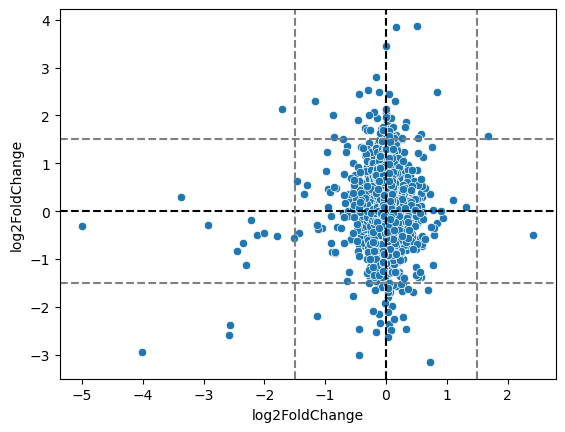

In [38]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

Text(0, 0.5, 'Gene-wise log2-fold change in \n Arabidopsis Cold Stress')

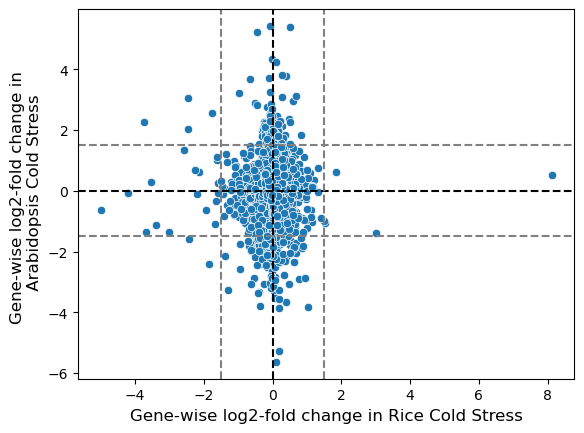

In [39]:
sns.scatterplot(x =tomato_genes_trimmed['log2FoldChange'], y = arabi_genes_trimmed['log2FoldChange'])
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.xlabel("Gene-wise log2-fold change in Rice Cold Stress", fontsize = 12)
plt.ylabel("Gene-wise log2-fold change in \n Arabidopsis Cold Stress", fontsize = 12)

In [40]:
new_merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]

In [41]:
new_merged_result['Classification'] = 'Non-substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_3228963/1856289886.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_3228963/1856289886.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Ser

Text(0, 0.5, 'Gene-wise log2-fold change in \n Arabidopsis Cold Stress')

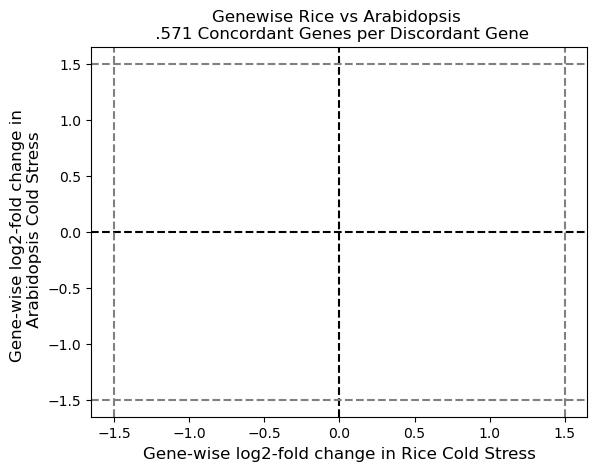

In [42]:
sns.scatterplot(data = new_merged_result.loc[new_merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10 )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.title('Genewise Rice vs Arabidopsis \n .571 Concordant Genes per Discordant Gene')
plt.xlabel("Gene-wise log2-fold change in Rice Cold Stress", fontsize = 12)
plt.ylabel("Gene-wise log2-fold change in \n Arabidopsis Cold Stress", fontsize = 12)

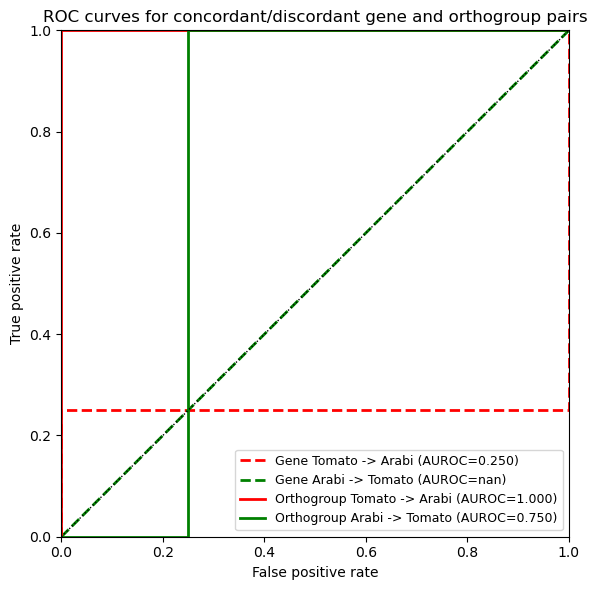

In [43]:
from sklearn.metrics import roc_curve


def calculate_threshold_exceedance_auroc(source_log2fc, target_log2fc, evaluation_threshold):
    paired_values = pd.DataFrame(
        {
            "source_log2fc": source_log2fc,
            "target_log2fc": target_log2fc,
        }
    ).dropna()

    substantial_pair_mask = (
        paired_values["source_log2fc"].abs() >= evaluation_threshold
    ) & (paired_values["target_log2fc"].abs() >= evaluation_threshold)
    paired_values = paired_values.loc[substantial_pair_mask].copy()

    paired_values = paired_values.loc[
        paired_values["source_log2fc"] * paired_values["target_log2fc"] != 0
    ].copy()
    paired_values["pair_class"] = "discordant"
    paired_values.loc[
        paired_values["source_log2fc"] * paired_values["target_log2fc"] > 0,
        "pair_class",
    ] = "concordant"

    target_positive_direction = paired_values["target_log2fc"] >= evaluation_threshold
    n_concordant = int((paired_values["pair_class"] == "concordant").sum())
    n_discordant = int((paired_values["pair_class"] == "discordant").sum())

    if target_positive_direction.nunique() < 2:
        return {
            "summary": {
                "auroc": float("nan"),
                "n_pairs": len(paired_values),
                "n_target_positive": int(target_positive_direction.sum()),
                "n_target_negative": int((~target_positive_direction).sum()),
                "n_concordant": n_concordant,
                "n_discordant": n_discordant,
            },
            "roc_curve": pd.DataFrame({"fpr": [0.0, 1.0], "tpr": [0.0, 1.0]}),
        }

    source_score_ranks = stats.rankdata(paired_values["source_log2fc"] )
    n_positive = int(target_positive_direction.sum())
    n_negative = int((~target_positive_direction).sum())
    positive_rank_sum = source_score_ranks[target_positive_direction.to_numpy()].sum()
    auroc = (
        positive_rank_sum - (n_positive * (n_positive + 1) / 2)
    ) / (n_positive * n_negative)
    fpr, tpr, _ = roc_curve(
        target_positive_direction.astype(int), paired_values["source_log2fc"]
    )

    return {
        "summary": {
            "auroc": auroc,
            "n_pairs": len(paired_values),
            "n_target_positive": n_positive,
            "n_target_negative": n_negative,
            "n_concordant": n_concordant,
            "n_discordant": n_discordant,
        },
        "roc_curve": pd.DataFrame({"fpr": fpr, "tpr": tpr}),
    }


def summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df, left_species_label, right_species_label, evaluation_threshold, pair_type
    ):
    left_to_right = calculate_threshold_exceedance_auroc(
        source_log2fc=paired_log2fc_df[left_species_label],
        target_log2fc=paired_log2fc_df[right_species_label],
        evaluation_threshold=evaluation_threshold,
    )
    right_to_left = calculate_threshold_exceedance_auroc(
        source_log2fc=paired_log2fc_df[right_species_label],
        target_log2fc=paired_log2fc_df[left_species_label],
        evaluation_threshold=evaluation_threshold,
    )

    summary_df = pd.DataFrame(
        [
            {
                "pair_type": pair_type,
                "prediction_direction": f"{left_species_label} -> {right_species_label}",
                **left_to_right["summary"],
            },
            {
                "pair_type": pair_type,
                "prediction_direction": f"{right_species_label} -> {left_species_label}",
                **right_to_left["summary"],
            },
        ]
    )
    roc_curve_df = pd.concat(
        [
            left_to_right["roc_curve"].assign(
                pair_type=pair_type,
                prediction_direction=f"{left_species_label} -> {right_species_label}",
            ),
            right_to_left["roc_curve"].assign(
                pair_type=pair_type,
                prediction_direction=f"{right_species_label} -> {left_species_label}",
            ),
        ],
        ignore_index=True,
    )

    return summary_df, roc_curve_df
gene_log2fc_pairs = pd.DataFrame(
    {
        "Tomato": tomato_genes_trimmed["log2FoldChange"].to_numpy(),
        "Arabi": arabi_genes_trimmed["log2FoldChange"].to_numpy(),
    }
)

orthogroup_log2fc_pairs = pd.DataFrame(
    {
        "Tomato": trimmed_tomato_ortho["log2FoldChange"].to_numpy(),
        "Arabi": trimmed_arabi_ortho["log2FoldChange"].to_numpy(),
    }
)

gene_auroc_summary, gene_roc_curves = summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df=gene_log2fc_pairs,
    left_species_label="Tomato",
    right_species_label="Arabi",
    evaluation_threshold=log_fc_change_evaluation_value,
    pair_type="Gene",
)

orthogroup_auroc_summary, orthogroup_roc_curves = summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df=orthogroup_log2fc_pairs,
    left_species_label="Tomato",
    right_species_label="Arabi",
    evaluation_threshold=log_fc_change_evaluation_value,
    pair_type="Orthogroup",
)

bidirectional_auroc_summary = pd.concat(
    [gene_auroc_summary, orthogroup_auroc_summary],
    ignore_index=True,
 )

bidirectional_roc_curves = pd.concat(
    [gene_roc_curves, orthogroup_roc_curves],
    ignore_index=True,
)


bidirectional_auroc_summary[[
    "pair_type",
    "prediction_direction",
    "auroc",
    "n_pairs",
    "n_concordant",
    "n_discordant",
    "n_target_positive",
    "n_target_negative",
]].round({"auroc": 3})
plot_colors = {
    "Tomato -> Arabi": "red",
    "Arabi -> Tomato": "green",
}
plot_linestyles = {
    "Orthogroup": "-",
    "Gene": "--",
}

plt.figure(figsize=(6, 6))
for _, summary_row in bidirectional_auroc_summary.iterrows():
    curve_subset = bidirectional_roc_curves.loc[
        (bidirectional_roc_curves["pair_type"] == summary_row["pair_type"])
        & (
            bidirectional_roc_curves["prediction_direction"]
            == summary_row["prediction_direction"]
        )
    ]
    plt.plot(
        curve_subset["fpr"],
        curve_subset["tpr"],
        color=plot_colors[summary_row["prediction_direction"]],
        linestyle=plot_linestyles[summary_row["pair_type"]],
        linewidth=2,
        label=(
            f"{summary_row['pair_type']} {summary_row['prediction_direction']} "
            f"(AUROC={summary_row['auroc']:.3f})"
        ),
    )

plt.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves for concordant/discordant gene and orthogroup pairs")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()

In [44]:
def get_ncbi_clean_og2gene_for_species(
    species_1, og2genes_only_cococonet, ncbi_mapping
):

    species_1_name = species_1

    first_species_ortho_groups = og2genes_only_cococonet.loc[
        og2genes_only_cococonet["Species"] == species_1
    ]
    shared_orthogroups = first_species_ortho_groups["Orthogroup"].unique()

    list_of_orthogene_pds = []
    for orthogroup in tq.tqdm(
        shared_orthogroups, desc="inner_loop", position=0, leave=False
    ):
        species_1_genes = (
            first_species_ortho_groups["Gene"]
            .loc[first_species_ortho_groups["Orthogroup"] == orthogroup]
            .to_list()
        )
        all_gene_combos = species_1_genes
        current_orthogroup_pd = pd.DataFrame(
            columns=[f"{species_1_name} OrthoGene"], data=all_gene_combos
        )
        current_orthogroup_pd["Orthogroup"] = orthogroup
        list_of_orthogene_pds.append(current_orthogroup_pd)

    final_species_lineup = pd.concat(list_of_orthogene_pds)
    ncbi_added_once = final_species_lineup.merge(
        right=ncbi_mapping[["Orthodb Gene", "Symbol"]],
        right_on="Orthodb Gene",
        left_on=f"{species_1_name} OrthoGene",
    )
    ncbi_added_once_clean = ncbi_added_once.drop(columns="Orthodb Gene")
    return ncbi_added_once_clean
og_groups = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/og_2_Genes_with_ncbi_symbol.csv"
)
og_groups
ncbi_mapping = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/merged_ncbi_to_orthodb_fixed_non_genesymbol.csv"
)

In [45]:
import tqdm as tq
arabi_og = get_ncbi_clean_og2gene_for_species(
    4558, og_groups, ncbi_mapping=ncbi_mapping
)

In [46]:
symbol_col = tomato_genes_trimmed.columns[0]
merged_gene_df = (
    arabi_genes_trimmed.rename(columns={"log2FoldChange": "Arabidopsis Log2FC"})
    [[symbol_col, "Arabidopsis Log2FC"]]
    .merge(
        right=arabi_og[["Symbol", "Orthogroup"]].drop_duplicates(
            subset="Symbol", keep="first"
        ),
        left_on=symbol_col,
        right_on="Symbol",
        how="left",
    )
    .drop(columns="Symbol")
    .merge(
        right=tomato_genes_trimmed.rename(
            columns={"log2FoldChange": "Tomato Log2FC"}
        )[[symbol_col, "Tomato Log2FC"]],
        on=symbol_col,
        how="inner",
    )
    [["Orthogroup", symbol_col, "Arabidopsis Log2FC", "Tomato Log2FC"]]
    .set_index(symbol_col)
)


gene_threshold = 1.5

merged_gene_df_arabi_threshold = merged_gene_df.loc[
    merged_gene_df["Arabidopsis Log2FC"].abs() > gene_threshold
] .copy()

merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] = merged_gene_df_arabi_threshold[
    "Orthogroup"
] .map(merged_ortho_df["Arabidopsis Log2FC"] )

merged_gene_df_arabi_threshold[
    "Orthogroup exceeds Arabidopsis threshold in same direction"
] = (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] > gene_threshold)
    & (merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] > gene_threshold)
) | (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] < -gene_threshold)
    & (merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] < -gene_threshold)
)

merged_gene_df_arabi_threshold
merged_gene_df_arabi_threshold[
    "Tomato exceeds threshold in same direction"
 ] = (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] > gene_threshold)
    & (merged_gene_df_arabi_threshold["Tomato Log2FC"] > gene_threshold)
) | (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] < -gene_threshold)
    & (merged_gene_df_arabi_threshold["Tomato Log2FC"] < -gene_threshold)
)

merged_gene_df_arabi_threshold

,Orthogroup,Arabidopsis Log2FC,Tomato Log2FC,Orthogroup Arabidopsis Log2FC,Orthogroup exceeds Arabidopsis threshold in same direction,Tomato exceeds threshold in same direction
arabidopsis Symbol,,,,,,
AT1G01240,NaN,-2.826846,0.081357,NaN,False,False
AT1G01500,NaN,1.659652,0.147328,NaN,False,False
AT1G01560,NaN,3.772441,0.396535,NaN,False,False
AT1G02370,NaN,1.734377,0.015709,NaN,False,False
AT1G02870,NaN,2.274333,-0.238625,NaN,False,False
...,...,...,...,...,...,...
AT5G63010,NaN,1.515138,-0.006534,NaN,False,False
AT5G63290,NaN,1.973414,0.003662,NaN,False,False
AT5G64040,NaN,-2.052459,0.506723,NaN,False,False


In [47]:
fisher_input_df = merged_gene_df_arabi_threshold[[
    "Orthogroup exceeds Arabidopsis threshold in same direction",
    "Tomato exceeds threshold in same direction",
]].copy()

fisher_contingency_table = pd.crosstab(
    fisher_input_df["Orthogroup exceeds Arabidopsis threshold in same direction"],
    fisher_input_df["Tomato exceeds threshold in same direction"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

fisher_odds_ratio, fisher_p_value = stats.fisher_exact(
    fisher_contingency_table.to_numpy(),
    alternative="greater",
)

fisher_exact_summary = pd.DataFrame(
    {
        "odds_ratio": [fisher_odds_ratio],
        "p_value": [fisher_p_value],
    }
)

fisher_contingency_table, fisher_exact_summary

(Tomato exceeds threshold in same direction          False  True 
 Orthogroup exceeds Arabidopsis threshold in sam...              
 False                                                 377      2
 True                                                    0      0,
    odds_ratio  p_value
 0         NaN      1.0)

In [62]:
non_missing_orthogroup_df = merged_gene_df_arabi_threshold.dropna(
    subset=["Orthogroup Arabidopsis Log2FC"]
 ).copy()

non_missing_fisher_input_df = non_missing_orthogroup_df[[
    "Orthogroup exceeds Arabidopsis threshold in same direction",
    "Tomato exceeds threshold in same direction",
]].copy()

non_missing_fisher_contingency_table = pd.crosstab(
    non_missing_fisher_input_df[
        "Orthogroup exceeds Arabidopsis threshold in same direction"
    ],
    non_missing_fisher_input_df["Tomato exceeds threshold in same direction"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

non_missing_fisher_odds_ratio, non_missing_fisher_p_value = stats.fisher_exact(
    non_missing_fisher_contingency_table.to_numpy(),
    alternative="greater",
)

non_missing_fisher_summary = pd.DataFrame(
    {
        "odds_ratio": [non_missing_fisher_odds_ratio],
        "p_value": [non_missing_fisher_p_value],
        "n_genes": [len(non_missing_orthogroup_df)],
    }
)

readable_non_missing_fisher_table = non_missing_fisher_contingency_table.rename(
    index={
        False: "Orthogroup below / opposite direction",
        True: "Orthogroup exceeds in same direction",
    },
    columns={
        False: "Tomato below / opposite direction",
        True: "Tomato exceeds in same direction",
    },
)

readable_non_missing_fisher_table["Row total"] = readable_non_missing_fisher_table.sum(
    axis=1
)
readable_non_missing_fisher_table.loc["Column total"] = readable_non_missing_fisher_table.sum(
    axis=0
)

display(readable_non_missing_fisher_table)
non_missing_fisher_summary

Tomato exceeds threshold in same direction,Tomato below / opposite direction,Tomato exceeds in same direction,Row total
Orthogroup exceeds Arabidopsis threshold in same direction,,,
Orthogroup below / opposite direction,0,0,0
Orthogroup exceeds in same direction,0,0,0
Column total,0,0,0


,odds_ratio,p_value,n_genes
0,NaN,1.0,0


In [48]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

0.5

In [49]:
all_over_1

,Tomato,Arabi


In [50]:
all_under_1

,Tomato,Arabi
2526,-1.845447,-2.398013
3103,-2.436440,-1.572145


In [51]:
merged_result

,Tomato,Arabi
0,-0.008752,0.707963
1,0.018003,0.012729
2,0.079179,0.301060
3,-0.269754,-0.033875
4,-0.073367,0.744674
...,...,...
2016,0.164117,-0.883490
2017,0.135438,-0.392489
2018,0.085511,-0.117255
2019,-0.218419,-1.164428


In [52]:
merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

pos_thresh = 0
neg_thresh = 0
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.5238461538461539
0.5238461538461539
0.5238461538461539
0.5238461538461539


In [53]:
stats.spearmanr(a=tomato_genes_trimmed['log2FoldChange'], b = arabi_genes_trimmed['log2FoldChange'] )

SignificanceResult(statistic=np.float64(0.04776241042020749), pvalue=np.float64(0.0005703528394619592))

In [54]:
down = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] <= -2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
up = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] >= 2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
down_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] <= -2)
    & (arabi_genes_trimmed["padj"] <= 0.001)
]
up_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] >= 2) & (arabi_genes_trimmed["padj"] <= 0.001)
]

In [55]:
down_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] <= -2)
    & (trimmed_arabi_ortho["padj"] <= 0.001)
]
up_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] >= 2) & (trimmed_arabi_ortho["padj"] <= 0.001)]

down_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] <= -2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]
up_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] >= 2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]

In [56]:
len(up_arabi_ortho.merge(how = "inner", right_index = True, left_index= True, right = up_ortho))

0

In [57]:
up_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj


In [58]:
up_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
110208at3193,2173.082255,3.870857,0.122154,31.688351,2.248368e-220,9.467879e-217
112624at3193,230.722909,3.848413,0.215084,17.892584,1.347150e-71,1.620813e-69
114446at3193,10656.890859,2.457080,0.107431,22.871309,8.970155e-116,2.905640e-113
119097at3193,32.270329,2.129589,0.341825,6.230057,4.662641e-10,2.769306e-09
120630at3193,41.320598,2.016177,0.297860,6.768876,1.297864e-11,8.675087e-11
121426at3193,1261.348893,3.441374,0.114897,29.951860,4.161179e-197,8.761363e-194
127580at3193,106.489371,2.522292,0.219401,11.496241,1.377869e-30,3.136329e-29
129717at3193,21.406466,2.305933,0.452301,5.098227,3.428494e-07,1.499209e-06
289567at3193,101.095601,2.069528,0.204296,10.130065,4.063807e-24,6.763910e-23
57896at3193,164.707011,2.001909,0.173500,11.538407,8.447556e-31,1.943861e-29


In [59]:
up

,arabidopsis Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rice_jp Symbol
1588,AT1G74310,84.095025,3.01336,0.488565,6.167781,6.925477e-10,6.232555e-07,Os05g0519700


In [60]:
up_arabi

,index,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rice_jp Symbol,arabidopsis Symbol
23,29785,30.061508,3.772441,0.533630,7.069392,1.556141e-12,1.174774e-11,Os08g0157000,AT1G01560
64,19661,236.416727,2.274333,0.180289,12.614919,1.747372e-36,5.870048e-35,Os05g0367100,AT1G02870
92,27706,759.077798,2.067614,0.118532,17.443543,3.854200e-68,4.723654e-66,Os05g0502800,AT1G03530
167,36321,17.136216,2.328981,0.525316,4.433482,9.272317e-06,3.430024e-05,Os11g0256200,AT1G05730
199,35651,1111.726596,2.010031,0.116297,17.283531,6.259540e-67,7.130660e-65,Os03g0333100,AT1G06720
...,...,...,...,...,...,...,...,...,...
4289,16784,34.451897,2.130153,0.370570,5.748316,9.013662e-09,4.834947e-08,Os03g0710700,AT4G39670
4506,14491,19.381315,2.106210,0.479063,4.396520,1.100005e-05,4.009884e-05,Os03g0822300,AT5G13830
4618,16963,522.402469,2.207816,0.151438,14.579002,3.820621e-48,2.226107e-46,Os03g0811800,AT5G20180
4701,18927,93.026208,2.457349,0.256136,9.593909,8.480985e-22,1.294807e-20,Os09g0418000,AT5G25110


In [61]:
up_arabi.merge(how = "inner", on = 'arabidopsis Symbol', right = up)

,index,baseMean_x,log2FoldChange_x,lfcSE_x,stat_x,pvalue_x,padj_x,rice_jp Symbol_x,arabidopsis Symbol,baseMean_y,log2FoldChange_y,lfcSE_y,stat_y,pvalue_y,padj_y,rice_jp Symbol_y
